In [ ]:
import os
import json
import xml.etree.ElementTree as ET

# set the label map for the dataset
# 0: with_mask, 1: without_mask, 2: mask_weared_incorrect
label_map = {
    "with_mask": 0,
    "without_mask": 1,
    "mask_weared_incorrect": 2
}

# set the directories for images and annotations
current_path = os.getcwd()
DATASET_DIR = os.path.join(current_path, "dataset")
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
ANNOTATIONS_DIR = os.path.join(DATASET_DIR, "annotations")
OUTPUT_JSON = os.path.join(DATASET_DIR,"dataset_coco.json")


In [ ]:
import os, torch, torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms
from torchvision.datasets.coco import CocoDetection
import matplotlib.pyplot as plt

In [ ]:
# ======================== Dataset ========================
DATA_ROOT = '/content/W25_COMP263_002_DeepLearning_Group1/dataset'
BATCH_SIZE = 4
NUM_CLASSES = 4  # 3 classes + background

class CocoDetectionFRCNN(CocoDetection):
    def __init__(self, img_folder, ann_file, transforms=None):
        super().__init__(img_folder, ann_file)
        self._transforms = transforms

    def __getitem__(self, idx):
        img, target = super().__getitem__(idx)
        image_id = self.ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=image_id)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'] + 1)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([image_id])
        }

        if self._transforms:
            img = self._transforms(img)

        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))

def get_dataset(split):
    path = os.path.join(DATA_ROOT, split)
    ann_file = os.path.join(path, '_annotations.coco.json')
    return CocoDetectionFRCNN(path, ann_file, transforms=transforms.ToTensor())

In [ ]:
# ======================== Loaders ========================
train_dataset = get_dataset('train')
val_dataset = get_dataset('valid')
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [ ]:
# ======================== Model ========================
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 165MB/s]


In [ ]:
# ======================== IoU ========================
def calculate_iou(pred_boxes, gt_boxes):
    ious = []
    for pb, gb in zip(pred_boxes, gt_boxes):
        xA = max(pb[0], gb[0])
        yA = max(pb[1], gb[1])
        xB = min(pb[2], gb[2])
        yB = min(pb[3], gb[3])
        interArea = max(0, xB - xA) * max(0, yB - yA)
        boxAArea = (pb[2] - pb[0]) * (pb[3] - pb[1])
        boxBArea = (gb[2] - gb[0]) * (gb[3] - gb[1])
        union = boxAArea + boxBArea - interArea
        iou = interArea / union if union > 0 else 0
        ious.append(iou)
    return sum(ious) / len(ious) if ious else 0

In [ ]:
# ======================== Training ========================
train_losses, val_losses, val_ious = [], [], []

for epoch in range(10):
    model.train()
    total_train_loss = 0
    for imgs, targets in train_loader:
        imgs = list(img.to(device) for img in imgs)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        loss = sum(loss for loss in loss_dict.values())
        total_train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_losses.append(total_train_loss)


    # ======================== Validation ========================
    model.eval()
    total_val_loss = 0
    iou_total = 0
    count = 0

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = list(img.to(device) for img in imgs)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            model.train()
            loss_dict = model(imgs, targets)
            model.eval()

            if isinstance(loss_dict, dict):
                loss = sum(loss for loss in loss_dict.values())
                total_val_loss += loss.item()
            else:
                print(f"⚠️ Skipped batch due to invalid loss_dict type: {type(loss_dict)}")
                continue

            # IoU
            predictions = model(imgs)
            for out, tgt in zip(predictions, targets):
                pred_boxes = out['boxes'].cpu()
                gt_boxes = tgt['boxes'].cpu()
                iou = calculate_iou(pred_boxes, gt_boxes)
                iou_total += iou
                count += 1


    val_losses.append(total_val_loss)
    val_ious.append(iou_total / count if count > 0 else 0)
    print(f"📍 Epoch {epoch+1} - Train Loss: {total_train_loss:.4f}, Val Loss: {total_val_loss:.4f}, Val IoU: {val_ious[-1]:.4f}")



📍 Epoch 1 - Train Loss: 73.6187, Val Loss: 98.0287, Val IoU: 0.3038
📍 Epoch 2 - Train Loss: 52.8917, Val Loss: 76.9721, Val IoU: 0.3036
📍 Epoch 3 - Train Loss: 48.1901, Val Loss: 67.0560, Val IoU: 0.3568
📍 Epoch 4 - Train Loss: 41.0809, Val Loss: 71.6021, Val IoU: 0.3807
📍 Epoch 5 - Train Loss: 38.4143, Val Loss: 61.7456, Val IoU: 0.3925
📍 Epoch 6 - Train Loss: 34.2742, Val Loss: 60.4068, Val IoU: 0.3875
📍 Epoch 7 - Train Loss: 35.0724, Val Loss: 65.2199, Val IoU: 0.3988
📍 Epoch 8 - Train Loss: 31.2888, Val Loss: 74.0769, Val IoU: 0.4260
📍 Epoch 9 - Train Loss: 30.4699, Val Loss: 58.0928, Val IoU: 0.4130
📍 Epoch 10 - Train Loss: 24.3065, Val Loss: 56.4233, Val IoU: 0.4181


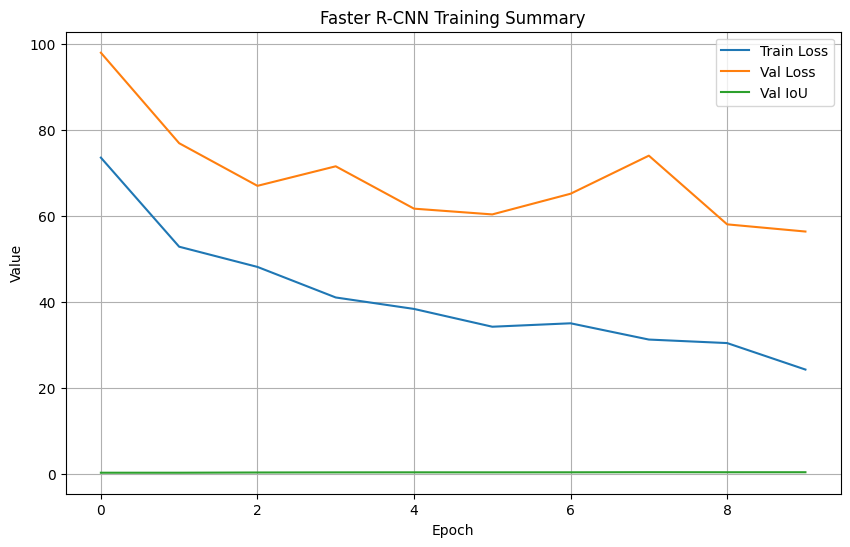

In [ ]:
# ======================== Save Model ========================
torch.save(model.state_dict(), "fasterrcnn_mask.pth")

# ======================== Plot Results ========================
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.plot(val_ious, label='Val IoU')
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Faster R-CNN Training Summary")
plt.legend()
plt.grid(True)
plt.show()